
1. Load dataset from Huggingface Hub and Create data generators (PyTorch)
   * Creating a dictionary containing image and mask from the dataset
   * Split dataset into train and validation sets
   * Perform id2label mapping (as done in Milestone 1)
   * Check if data and labels are getting correctly loaded

2. Create PyTorch dataset. Each item in the dataset contains image and corresponding ground truth mask
   * Write functions to apply image transformation to image and mask (e.g resizing to 224x 224 pixels)
   * Apply transformations to train and test datasets
   * Convert image to RGB and cast to float32 type
   * Normalize image and mask so the range of values in them is between (0,1)
   * Creare the train and test datasets using Dataset module from Pytorch utils

3. Create PyTorch DataLoaders for train and test data
  * Define a custom collate function
  * Use the preprocessor of MaskFormer, to turn the images + mask into the format MaskFormer model expects
  * Get training and test batches of the dataset specifying batch size
  * Print information about the shapes of tensor data in the batch

4. Load, train and evaluate model
  * Load a Maskformer model with checkpoint facebook/maskformer-swin-base-ade
  * Set the evaluation metric to "meanIOU"
  * Write a training loop to train model for at least 20 epochs
  * Print mIOU after every epoch
  * Push trained model to Huggingface hub after logging in to your Huggingface account

5. Inference
  * Load 10 images from the test dataloader
  * Predict on 10 images
  * Display original image, mask and prediction together
  * Use the mean IOU function you implemented in MS1 to compute IOU for 10 images
  * Print mean IOU scores

In [1]:
!pip install transformers==4.31.0

In [2]:
!pip install -q datasets

In [3]:
!pip install -q albumentations

In [4]:
# Import necessary libraries
import numpy as np
import pandas as pd
import os

from PIL import Image  # Python Imaging Library for image processing
from matplotlib import pyplot as plt  # Plotting library for visualizations
import glob  # File path matching using patterns
import cv2  # OpenCV library for computer vision tasks


In [5]:
# load MRI dataset which you created in MS1 and uploaded on Huggingface
from huggingface_hub import login
login(token='Your token') # # The login token should be kept private and refreshed periodically through your Huggingface account.


Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to /root/.cache/huggingface/token
Login successful


In [6]:
from datasets import load_dataset

# Import the load_dataset function from the datasets module
from datasets import load_dataset

# Load the MRI_dataset using the load_dataset function
# Note: You will need to provide the complete dataset name that you used while creating it in MS1
# For example, load_dataset("username/datasetname", split="train")

dataset = load_dataset("akar49/MRI_Segmentation-1") ## Dataset uploaded by author



/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [7]:
## Display contents of the loaded dataset
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 500
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 200
    })
})

In [8]:
# Extract the training dataset from the loaded dataset
train_ds = dataset["train"]

# Extract the testing/validation dataset from the loaded dataset
test_ds = dataset["validation"]


# Create PyTorch dataset. Each item in the dataset contains image and corresponding ground truth mask
* Write functions to apply image transformation to image and mask (e.g resizing to 224)
* Apply transformations to train and test datasets
* Convert image to RGB and cast to float32 type
* Normalize image and mask so the range of values in them is between (0,1)
* Creare the train and test datasets using Dataset module from Pytorch utils

In [15]:
import numpy as np
from torch.utils.data import Dataset

class ImageSegmentationDataset(Dataset):
    """Image segmentation dataset."""

    def __init__(self, dataset, transform):
        """
        Constructor for the ImageSegmentationDataset class.

        Args:
            dataset (list): The dataset containing image and label pairs.
            transform (callable): A transformation to be applied to the data.
        """
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        """
        Get the length of the dataset.

        Returns:
            int: The number of samples in the dataset.
        """
        return len(self.dataset)

    def __getitem__(self, idx):
        """
        Get a sample from the dataset.

        Args:
            idx (int): Index of the sample.

        Returns:
            tuple: A tuple containing the transformed image, segmentation map,
                   original image, and original segmentation map.
        """
        # Extract image and label from the dataset
        im = np.array(self.dataset[idx]['image'])
        original_image = cv2.cvtColor(im, cv2.COLOR_GRAY2RGB) / 255.0
        original_image = np.float32(original_image)
        original_segmentation_map = np.array(self.dataset[idx]['label']) / 255.0

        # Apply the specified transformation to the data
        transformed = self.transform(image=original_image, mask=original_segmentation_map)
        image, segmentation_map = transformed['image'], transformed['mask']

        # Transpose the image dimensions for compatibility with PyTorch
        image = image.transpose(2, 0, 1)

        # Return the transformed image, segmentation map, original image, and original segmentation map
        return image, segmentation_map, original_image, original_segmentation_map



In [10]:
import albumentations as A

# Define the training data transformation using Albumentations
train_transform = A.Compose([
    A.Resize(width=224, height=224)  # Resize the image and label to the specified dimensions
])

# Define the testing/validation data transformation using Albumentations
test_transform = A.Compose([
    A.Resize(width=224, height=224)  # Resize the image and label to the specified dimensions
])

# Create ImageSegmentationDataset instances for training and testing/validation datasets
train_dataset = ImageSegmentationDataset(train_ds, transform=train_transform)
test_dataset = ImageSegmentationDataset(test_ds, transform=test_transform)


#  Create id2label mapping
* See step 2 of Milestone 1

In [16]:
id2label = {
    0:  'bg',
    1:  'tumor',

}
label2id = { label: id for id, label in id2label.items() }
n_classes = len(id2label)
n_classes

2

# Create PyTorch DataLoaders for train and test data
* Define a custom s"collate function"
* Use the preprocessor of MaskFormer, to turn the images + maps into the format MaskFormer model expects
* Get training and batches of the dataset specifying batch size
* Run verifications -print dimensions of original data and input tensors created by the dataloader, mask dimensions and input mask labels
* Display mask regions according to label- tumor or background


In [17]:
# Import the MaskFormerImageProcessor from the transformers module
from transformers import MaskFormerImageProcessor

# Create an instance of the MaskFormerImageProcessor with specified parameters
preprocessor = MaskFormerImageProcessor(
    ignore_index=255,       # Ignore pixels with this index during processing
    reduce_labels=False,    # Do not reduce the number of labels
    do_resize=False,        # Do not perform resizing
    do_rescale=False,       # Do not perform rescaling
    do_normalize=False      # Do not perform normalization
)




In [18]:
# Import the DataLoader from the torch.utils.data module
from torch.utils.data import DataLoader

def collate_fn(batch):
    """
    Custom collate function for DataLoader.

    Args:
        batch (list): A list of samples, each containing transformed image, segmentation map,
                      original image, and original segmentation map.

    Returns:
        dict: A dictionary containing processed batch data.
    """
    # Unpack the input batch into separate lists for images and segmentation maps
    inputs = list(zip(*batch))
    images = inputs[0]
    segmentation_maps = inputs[1]

    # Apply the MaskFormerImageProcessor to the batch
    batch = preprocessor(
        images,
        segmentation_maps=segmentation_maps,
        return_tensors="pt",
    )

    # Add original images and segmentation maps to the processed batch
    batch["original_images"] = inputs[2]
    batch["original_segmentation_maps"] = inputs[3]

    return batch

# Create DataLoader instances for training and testing/validation datasets
train_dataloader = DataLoader(
    train_dataset, batch_size=2, shuffle=True, num_workers=2, collate_fn=collate_fn
)
test_dataloader = DataLoader(
    test_dataset, batch_size=2, shuffle=False, num_workers=2, collate_fn=collate_fn
)


In [20]:
import torch
batch = next(iter(train_dataloader))

# Print information about the shapes of tensor data in the batch
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(k, v.shape)
    else:
        print(k, v[0].shape)

# Convert numerical class labels to corresponding string labels using id2label mapping
labels = [id2label[label] for label in batch["class_labels"][0].tolist()]

# Print the string labels
print(labels)


pixel_values torch.Size([2, 3, 224, 224])
pixel_mask torch.Size([2, 224, 224])
mask_labels torch.Size([2, 224, 224])
class_labels torch.Size([2])
original_images (512, 512, 3)
original_segmentation_maps (512, 512)
['bg', 'tumor']


In [21]:
!pip install -q evaluate

In [22]:
# Import the evaluate module
import evaluate

# Load the "mean_iou" metric from the evaluate module
metric = evaluate.load("mean_iou")



# Load, train and evaluate model
* Load a Maskformer model with checkpoint facebook/maskformer-swin-base-ade
* Set the evaluation metric to "meanIOU"
* Write a training loop to train model for at least 20 epochs
* Print mIOU after every epoch.
* Push trained model to Huggingface hub

In [23]:
from transformers import MaskFormerForInstanceSegmentation

# Replace the head of the pre-trained model
model = MaskFormerForInstanceSegmentation.from_pretrained("facebook/maskformer-swin-base-ade",
                                                          id2label=id2label,
                                                          ignore_mismatched_sizes=True)

Some weights of MaskFormerForInstanceSegmentation were not initialized from the model checkpoint at facebook/maskformer-swin-base-ade and are newly initialized because the shapes did not match:
- class_predictor.weight: found shape torch.Size([151, 256]) in the checkpoint and torch.Size([3, 256]) in the model instantiated
- class_predictor.bias: found shape torch.Size([151]) in the checkpoint and torch.Size([3]) in the model instantiated
- criterion.empty_weight: found shape torch.Size([151]) in the checkpoint and torch.Size([3]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
len(test_dataloader.dataset)

200

In [25]:
# Import necessary libraries
import torch
from tqdm.auto import tqdm

# Check if GPU is available and set the device accordingly
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define the Adam optimizer with a learning rate of 5e-5
optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

# Initialize variables for tracking running loss and the number of samples
running_loss = 0.0
num_samples = 0

# Training loop for 20 epochs
for epoch in range(20):
    print("Epoch:", epoch)

    # Set the model to training mode
    model.train()

    # Iterate through batches in the training dataloader
    for idx, batch in enumerate(tqdm(train_dataloader)):
        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(
            pixel_values=batch["pixel_values"].to(device),
            mask_labels=[labels.to(device) for labels in batch["mask_labels"]],
            class_labels=[labels.to(device) for labels in batch["class_labels"]],
        )

        # Compute loss and backward pass
        loss = outputs.loss
        loss.backward()

        # Update running loss and number of samples
        batch_size = batch["pixel_values"].size(0)
        running_loss += loss.item()
        num_samples += batch_size

        # Print running loss every 100 batches
        if idx % 100 == 0:
            print("Loss:", running_loss / num_samples)

        # Update model parameters
        optimizer.step()

    # Set the model to evaluation mode
    model.eval()

    # Iterate through batches in the testing/validation dataloader
    for idx, batch in enumerate(tqdm(test_dataloader)):
        pixel_values = batch["pixel_values"]

        # Forward pass without gradient computation
        with torch.no_grad():
            outputs = model(pixel_values=pixel_values.to(device))

        # Extract original images and target sizes
        original_images = batch["original_images"]
        target_sizes = [(image.shape[0], image.shape[1]) for image in original_images]

        # Post-process predicted segmentation maps
        predicted_segmentation_maps = preprocessor.post_process_semantic_segmentation(
            outputs, target_sizes=target_sizes
        )

        # Extract ground truth segmentation maps
        ground_truth_segmentation_maps = batch["original_segmentation_maps"]

        # Add batch to the evaluation metric
        metric.add_batch(references=ground_truth_segmentation_maps, predictions=predicted_segmentation_maps)

    # Compute and print the mean IoU for the current epoch
    mean_iou = metric.compute(num_labels=len(id2label), ignore_index=0)["mean_iou"]
    print("Mean IoU:", mean_iou)


Epoch: 0


  0%|          | 0/250 [00:00<?, ?it/s]

Loss: 1.1014659404754639
Loss: 0.32836231264737575
Loss: 0.23617678341358456


  0%|          | 0/100 [00:00<?, ?it/s]

/root/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--mean_iou/08bc20f4f895f3caf75fb9e3fada1404bded3c3265243d05327cbb3b9326ffe9/mean_iou.py:260: RuntimeWarning: invalid value encountered in divide
  acc = total_area_intersect / total_area_label


...

Mean IoU: 0.45911223893823133
Epoch: 19


  0%|          | 0/250 [00:00<?, ?it/s]

Loss: 0.047654007760471885
Loss: 0.04719291226924928
Loss: 0.046668792669790196


  0%|          | 0/100 [00:00<?, ?it/s]

Mean IoU: 0.4745438342094133


In [26]:
#Upload model to Huggingface hub
model.push_to_hub("Maskformer-MRIseg_model_Mar24")


pytorch_model.bin:   0%|          | 0.00/411M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/akar49/Maskformer-MRIseg_model_Mar24/commit/4c49f77b7cd9349d07a24f70e9080337577d7803', commit_message='Upload MaskFormerForInstanceSegmentation', commit_description='', oid='4c49f77b7cd9349d07a24f70e9080337577d7803', pr_url=None, pr_revision=None, pr_num=None)

# Inference
* Load 10 images from the test dataloader
* Predict on 10 images
* Display original image, mask and prediction together
* Write a function to compute Dice score for the 10 images
* Print Dice scores


In [27]:
# Create a DataLoader instance for the testing/validation dataset with a batch size of 10
# The shuffle parameter is set to True for randomizing the order of samples in each epoch
# The collate_fn parameter is set to the previously defined custom collate function collate_fn
test_dataloader = DataLoader(test_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)


In [28]:
# let's take the first test batch
# Retrieve a batch of data from the testing/validation dataloader
batch = next(iter(test_dataloader))

# Print information about the shapes of tensor data in the batch
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(k, v.shape)
    else:
        print(k, len(v))


pixel_values torch.Size([10, 3, 224, 224])
pixel_mask torch.Size([10, 224, 224])
mask_labels 10
class_labels 10
original_images 10
original_segmentation_maps 10


In [29]:
## Run the model on the input data
with torch.no_grad():
  outputs = model(batch["pixel_values"].to(device))


In [30]:
# predict segmentation maps
original_images = batch["original_images"]
target_sizes = [(image.shape[0], image.shape[1]) for image in original_images]

predicted_segmentation_maps = preprocessor.post_process_semantic_segmentation(outputs, target_sizes=target_sizes)


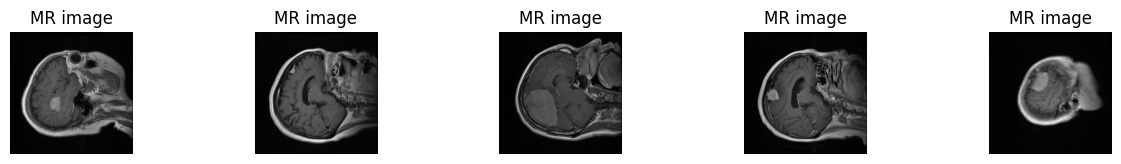

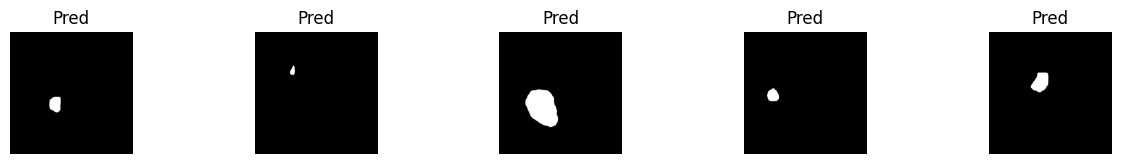

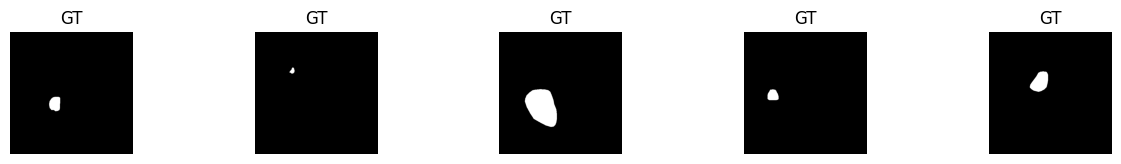

In [31]:
# Set the number of images to display
nims = 5

# Visualize original images
plt.figure(figsize=(30, 30))
for i in range(nims):
    plt.subplot(1, 10, i + 1)

    # Extract and convert the original image to uint8
    image = batch["original_images"][i]
    image = (image * 255).astype(np.uint8)
    im = Image.fromarray(image)

    # Display the original image
    plt.imshow(im)
    plt.axis('off')
    plt.title("MR image")
    plt.subplots_adjust(wspace=1, hspace=0)

plt.show()

# Visualize predicted segmentation maps
plt.figure(figsize=(30, 30))
for i in range(nims):
    plt.subplot(1, 10, i + 1)

    # Extract and display the predicted segmentation map
    pred = predicted_segmentation_maps[i].cpu().numpy()
    plt.imshow(pred, cmap='gray')
    plt.axis('off')
    plt.title("Pred")
    plt.subplots_adjust(wspace=1, hspace=0)

plt.show()

# Visualize ground truth segmentation maps
plt.figure(figsize=(30, 30))
for i in range(nims):
    plt.subplot(1, 10, i + 1)

    # Extract and display the ground truth segmentation map
    gt = batch["original_segmentation_maps"][i]
    plt.imshow(gt, cmap='gray')
    plt.axis('off')
    plt.title("GT")
    plt.subplots_adjust(wspace=1, hspace=0)

plt.show()


## Estimate mIOU score on predictions (use the calcIoU function implemented in MS1)

In [32]:
# Use the function you developed in MS1 to estimate the mean Intersection over Union (IoU) for Maskformer
def calculate_iou(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    iou = np.sum(intersection) / np.sum(union)
    return iou

def calculate_mean_iou(y_true, y_pred):
    class_iou = []
    for i in range(1, np.max(y_true) + 1):
        y_true_i = (y_true == i)
        y_pred_i = (y_pred == i)
        class_iou.append(calculate_iou(y_true_i, y_pred_i))
    mean_iou = np.mean(class_iou)
    return mean_iou


## Print IOU values

In [34]:
# Iterate through the first 10 samples in the batch
for i in range(10):
    # Extract and convert the predicted segmentation map to a NumPy array
    pred = predicted_segmentation_maps[i].cpu().numpy()

    # Extract the ground truth segmentation map
    gt = batch["original_segmentation_maps"][i]

    # Calculate and print the Intersection over Union (IoU) for the current pair of masks
    iou_score = calculate_mean_iou(pred, gt)
    print("mean IoU Score for Sample {}: {}".format(i, iou_score))


mean IoU Score for Sample 0: 0.8876447876447876
mean IoU Score for Sample 1: 0.5854092526690391
mean IoU Score for Sample 2: 0.9428499017930685
mean IoU Score for Sample 3: 0.836105675146771
mean IoU Score for Sample 4: 0.8705782673162465
mean IoU Score for Sample 5: 0.8454921949665498
mean IoU Score for Sample 6: 0.872852912142152
mean IoU Score for Sample 7: 0.9329684048785173
mean IoU Score for Sample 8: 0.8062934205149163
mean IoU Score for Sample 9: 0.9212733511246665
